## Chapter 5 Hypothesis Testing
#### MA 189 Data Dive Into Birmingham (with R)
##### _Blazer Core: City as Classroom_


Course Website: [github.com/tphilli2/datadiveintobirmingham](https://github.com/tphilli2/datadiveintobirmingham) 


#### Levels:
<div class="alert-success"> Concepts and general information</div>
<div class="alert-warning"> Important methods and technique details </div>
<div class="alert-info"> Extended reading </div>
<div class="alert-danger"> (Local) Examples, assignments, and <b>Practice in Birmingham</b> </div>

##### <div class="alert alert-block alert-success"> Introduction </div>

Read the following story about Robert Swain, a Black man living in Talladega County, Alabama in 1965. In the county, 26% of those eligible for jury were Black but he went to trial with an all white jury. 

[![Reading: Robert Swain Legal Case](https://ajr348.github.io/ds4e_course/chapters/04_stats1/03_testing_hypotheses_1.html)](https://ajr348.github.io/ds4e_course/chapters/04_stats1/03_testing_hypotheses_1.html) (scroll down to start at Swain v Alabama)


This historical legal case in Alabama gives us motivation for the important method of hypothesis testing which allows us to make conclusions about a population value based on evidence from sample values. 

By the end of this chapter, you will have the skills to perform a hypothesis test of your own.

<div class="alert alert-block alert-danger">
    <b>Application in Birmingham from Area of E-commerce </b>
</div>

As a further motivation for this chapter, consider the video below from Mr. Brad Kilpatrick of World Rugby Shop located here in Birmingham, AL. Mr. Kilpatrick explains his use of hypothesis testing in E-commerce. He dives into the details of the process of split-testing (which compares the performance of two versions of content to see which one appeals more to visitors/viewers) with website traffic with the goal of increasing sales and conversion rates (percentage of users completing an action desired by the company).



[![Video: World Rugby Shop Hypothesis Testing](https://youtu.be/NB0B8BRZS2A)](https://youtu.be/NB0B8BRZS2A)





### Hypothesis Testing

This method allows researchers to check whether data supports certain statements or predictions about a population. Hypotheses are usually expressed as population parameters for variables being measured in the study.

##### <div class="alert alert-block alert-success"> Hypotheses </div>

* A __null hypothesis__, $H_0$, is a statement that a population parameter is a particular value. 

* An __alternative hypothesis__, $H_a$, is a statement that the same population parameter falls in some alternative range of values. 


<div class="alert alert-block alert-danger"><b> Example:</b></div>


1. In auto racing, a pit crew claims that its mean pit stop time (for 4 new tires and fuel) is only 13 seconds. The driver thinks it's more and wants to investigate for efficiency purposes. 
2. Cocoa Puffs boxes claim there is an average of 19.3oz of cereal in the box. A grumpy college student believes the box contains less than 19.3oz and wants to find out more. 
3. According to Indeed.com, the average base salary for mechanical engineers in Alabama is \$100,272. You doubt this is accurate.



##### Your answer:

<div class="alert alert-block alert-danger"><b>Local Student Practice:</b> Hypotheses in Birmingham

</div>


1. Katrina hypothesizes that 90\% of college graduates from UAB believe a college degree is worth the cost. You disagree with her on her estimate.

2. A researcher finds that the mean pH level of the Cahaba River is 7.5 (https://www.researchgate.net/publication/268328332_Water_Quality_Conditions_in_the_Cahaba_River_and_Likely_Pollutant_Sources#pf35). An industrial company has reason to believe its lower. 

3. You think the average age of all lawyers in Birmingham is 43. Your friend challenges you on your estimate and wants to conduct a hypothesis test to gain more information.

4. According to this report (https://downtownbhm.com/wp-content/uploads/2024/04/Q3-Q4-2023-Data-Report-FINAL-1.pdf), the office occupancy in downtown Birmingham is 77.6%. You think it's higher and want to investigate yourself. 

5. It is claimed that Alabama's three oil refineries combined can process on average 142,000 barrels of crude oil per day (https://www.eia.gov/state/analysis.php). You are hesitant about the validity of that number and believe it's lower.







##### Your answer:

##### <div class="alert alert-block alert-success"> Hypothesis Tests </div>

Overview: 

* __Assumptions__: differ depending on the type of hypothesis test one is planning to perform (proportion, mean, one sample, two samples). Specifics are given in subsequent sections. 

* A __test statistic__ describes how many standard deviations the point estimate falls from the null hypothesis value.

* The __$p$-value__ is the probability that a given result (or a more significant result) would occur under the null hypothesis. <br>
Note: <br>
-Small $p$-value $\Rightarrow$ data is unlikely to have occurred under null hypothesis (i.e. assuming null hypothesis is true) $\Rightarrow$  strong evidence against null hypothesis. <br>
-Big $p$-value $\Rightarrow$ data is likely to have occurred under null hypothesis (i.e. assuming null hypothesis is true) $\Rightarrow$ not enough evidence against null hypothesis.<br>

* The __level of significance__, $\alpha$, is the maximum allowed probability of rejecting $H_0$ when it is actually true. <br>
Note: Most commonly, $\alpha=0.05$ or $\alpha=0.01$. The more important the context of a study is, the smaller $\alpha$ should be (for example, a cancer study versus a study on car color). We determine whether the $p$-value is small by comparing it with $\alpha.$





Hypothesis Test:
1. Identify the parameter ($p$ or $\mu$) and both hypotheses ($H_0$ and $H_a$) 
2. Decide if a normal distribution (for $p$) or a $t-$distribution (for $\mu$) is appropriate (check assumptions)
3. Use sample data to run test (get test statistic)
4. Decide if it would be unusual to get those results by chance ($p$-value sufficiently small) 
5. Conclude <br>
-If results are unusual ($p$-value sufficiently small, $H_0$ rare to occur), then reject $H_0$ in favor of $H_a$.<br>
-If results are not unusual ($p$-value sufficiently big, $H_0$ likely to occur), then the evidence is not strong enough to reject $H_0$. <br>

Important: Hypothesis Tests __never prove__ the null hypothesis. <br>
-If $p$-value $\leq \alpha$, the results are statistically significant. Reject $H_0$. "There is sufficient evidence to conclude that....(describe alternative hypothesis)." <br>
-If $p$-value $> \alpha$, the results are $\underline{not}$ statistically significant. Fail to reject $H_0$. "There is $\underline{not}$ sufficient evidence to reject the belief that....(describe null hypothesis)." 

Statistically significant results mean they are unlikely to happen by chance variation between samples (the expected random variability). 


In [ ]:
# Set up the parameters for the normal distribution
mu_null <- 500   # Null hypothesis mean (H0)
sd <- 10         # Standard deviation of the population
n <- 30          # Sample size
se <- sd / sqrt(n)  # Standard error of the mean
alpha <- 0.05    # Significance level (for a two-tailed test)

# Define the critical z-value for a two-tailed test
z_critical <- qnorm(1 - alpha/2)  # Critical value for a 95% confidence level

# Create a sequence of x values for plotting the normal distribution
x_values <- seq(mu_null - 4*se, mu_null + 4*se, length = 1000)

# Calculate the normal distribution (probability density function)
y_values <- dnorm(x_values, mean = mu_null, sd = se)

# Plot the normal distribution
plot(x_values, y_values, type = "l", lwd = 2, col = "blue",
     xlab = "Sample Mean", ylab = "Density",
     main = "Hypothesis Testing: Normal Distribution of Sample Means")

# Shade the critical regions (reject H0)
x_critical_left <- seq(min(x_values), mu_null - z_critical*se, length = 100)
x_critical_right <- seq(mu_null + z_critical*se, max(x_values), length = 100)
y_critical_left <- dnorm(x_critical_left, mean = mu_null, sd = se)
y_critical_right <- dnorm(x_critical_right, mean = mu_null, sd = se)

# Shade the rejection regions (critical regions)
polygon(c(min(x_critical_left), x_critical_left, max(x_critical_left)), c(0, y_critical_left, 0), col = rgb(1, 0, 0, 0.2), border = NA)
polygon(c(min(x_critical_right), x_critical_right, max(x_critical_right)), c(0, y_critical_right, 0), col = rgb(1, 0, 0, 0.2), border = NA)

# Annotate the critical regions
text(mu_null - z_critical*se - .5*se, 0.02, "Reject H0", col = "red", pos = 3)
text(mu_null + z_critical*se + .5*se, 0.02, "Reject H0", col = "red", pos = 3)

# Add a vertical line at the null hypothesis mean (H0)
abline(v = mu_null, col = "black", lwd = 2, lty = 2)

# Add arrows and text to show the acceptance region
arrows(mu_null - z_critical*se + 2*se, 0.04, mu_null - 2*se, 0.04, length = 0.1, col = "green", lwd = 2)
arrows(mu_null + z_critical*se - 2*se, 0.04, mu_null + 2*se, 0.04, length = 0.1, col = "green", lwd = 2)
text(mu_null, 0.05, "Do not reject H0", col = "green", pos = 3)


### One Sample

Hypothesis testing allows us to investigate whether the difference between a sample statistic and a presumed population parameter can be explained by random variability (in which the presumed population parameter cannot be rejected) or not (and the sample statistic is therefore unlikely to have occurred under the case of the presumed population parameter value and so the parameter value must be rejected).

##### <div class="alert alert-block alert-success"> One Sample Population Proportion Hypothesis Test </div>

Null Hypothesis: $H_0: p=p_0$<br>
Alternative Hypothesis: $H_a: p>p_0$ OR $H_a: p<p_0$ OR $H_a: p\neq p_0$

Assumptions:
1. Data obtained by randomization
2. $np_0\geq 15$ and $n(1-p_0)\geq 15$

Test Statistic: $z=\displaystyle \frac{\hat{p}-p_0}{\sqrt{\frac{p_0(1-p_0)}{n}}}$



<div class="alert alert-block alert-danger">
    <b>Local Student Example: </b> Swain vs. Alabama
</div>

Consider again the Swain vs. Alabama historical legal case from the introduction of this chapter (https://ajr348.github.io/ds4e_course/chapters/04_stats1/03_testing_hypotheses_1.html). 

Read the first part of this section contextualizing the case in the framework of a hypothesis test:
https://ajr348.github.io/ds4e_course/chapters/04_stats1/04_testing_hypotheses_2.html

1. What is the conclusion of the hypothesis test based on the evidence from these readings? (Note: they explain the process slightly differently than we will do but same idea in general).
2. State the null and alternative hypotheses.
3. Perform a hypothesis test and state your conclusions.
4. Do your conclusions match the conclusions from the reading? 

<p align="center">
    <img src="pics/zscoresnegative.png" alt="Figure 1" style="width:70%;"/>
</p>

<p align="center">
    <img src="pics/zscorespositive.png" alt="Figure 1" style="width:70%;"/>
</p>

##### Your answer:

<div class="alert alert-block alert-danger">
    <b>Example: </b> Promotion File Study
</div>

In a 1972 experiment, 48 male bank supervisors each judged a file to decide whether or not the person should receive a promotion. The files were IDENTICAL besides that half were labeled "male" and the other half labeled "female." In total, 35 files were recommended for promotion—21 "male" files and 14 "female" files. Was there bias present against "female" files?

##### Your answer:

After completing the work, you can read more about this experiment here if interested (https://openintro-ims.netlify.app/foundations-randomization). 

##### <div class="alert alert-block alert-success"> One Sample Population Mean Hypothesis Test (One Sample $t$-test) </div>

Null Hypothesis: $H_0: \mu=\mu_0$<br>
Alternative Hypothesis: $H_a: \mu>\mu_0$ OR $H_a: \mu<\mu_0$ OR $H_a: \mu\neq \mu_0$

Assumptions: 
1. Data obtained by randomization.
2. Approximately normal population or $n\geq 30$.

Test Statistic: $t=\frac{\bar{x}-\mu_0}{\frac{s}{\sqrt{n}}}$ and $df=n-1$.

Note: if $\sigma$ is known, you may use $z$-score with $\sigma$ instead of $t$-score with $s.$



<div class="alert alert-block alert-danger">
    <b>Local Application: </b> World Rugby Shop Page Views
</div>

The World Rugby Shop, based here in Birmingham, keeps careful records of its data. Consider the total number of page views for rugby shorts each week from users in Canada, the US, and the UK combined. 

1. Take a quick look at the data and make a hypothesis for what the average weekly number of pageviews is for this item. 
2. For sake of example, let's say someone believes it is 260 but you believe it is higher. You want to investigate this by taking a sample of 30 randomly selected weeks from available data from June 2020-April 2022 and performing a hypothesis test to test the belief that the average number of weekly views is higher than the hypothesized value (using $\alpha=0.05).$


In [ ]:
# Install and load the necessary package

install.packages("openxlsx")
library(openxlsx)

#alternative way to read excel
#install.packages("readxl")
#library(readxl)
#if (!require(readxl)) {
 # install.packages("readxl")
  #library(readxl)
#}

# Define the path to the Excel file
file_path <- "data/WRS Shorts Data - Canada, Australia, UK.xlsx"

# Read the Excel file from the "data" subfolder
WRS_data <- read.xlsx(file_path)
WRS_data

##### Your answer:

In [ ]:
#this is a list of 30 randomly selected data points for pageviews for a common class example
x <- c(94,141,476,253,940,648,192,183,161,223,131,233,344,1118,455,425,121,243,258,349,162,416,521,390,424,365,606,349,420,380) 
length(x)
sd(x)
mean(x)


In [ ]:
#here is an example (commented out) for how to select 30 random values using syntax 
#instead of choosing them manually
#n <- nrow(WRS_data)
#sample_index <- sample(1:n,30)
#WRS_data_sample <- WRS_data[sample_index,]$`Total.Pageviews`
#WRS_data_sample

##### t-Distribution Table (Critical Values)

Important Note: The $\alpha$ values in this table correspond to the amount of area in the tails of the distribution for that t-score and corresponding df value; it only has direct relation to the significance level of a hypothesis test when working with a two-tailed test (which we will work with soon). 

| Degrees of Freedom (df) | 90% CI (α = 0.10) | 95% CI (α = 0.05) | 98% CI (α = 0.02) | 99% CI (α = 0.01) |
|-------------------------|-------------------|-------------------|-------------------|-------------------|
| 1                       | 6.314             | 12.706            | 31.821            | 63.657            |
| 2                       | 2.920             | 4.303             | 6.965             | 9.925             |
| 3                       | 2.353             | 3.182             | 4.541             | 5.841             |
| 4                       | 2.132             | 2.776             | 3.747             | 4.604             |
| 5                       | 2.015             | 2.571             | 3.365             | 4.032             |
| 6                       | 1.943             | 2.447             | 3.143             | 3.707             |
| 7                       | 1.895             | 2.365             | 2.998             | 3.499             |
| 8                       | 1.860             | 2.306             | 2.896             | 3.355             |
| 9                       | 1.833             | 2.262             | 2.821             | 3.250             |
| 10                      | 1.812             | 2.228             | 2.764             | 3.169             |
| 11                      | 1.796             | 2.201             | 2.718             | 3.106             |
| 12                      | 1.782             | 2.179             | 2.681             | 3.055             |
| 13                      | 1.771             | 2.160             | 2.650             | 3.012             |
| 14                      | 1.761             | 2.145             | 2.624             | 2.977             |
| 15                      | 1.753             | 2.131             | 2.602             | 2.947             |
| 20                      | 1.725             | 2.086             | 2.528             | 2.845             |
| 25                      | 1.708             | 2.060             | 2.485             | 2.787             |
| 30                      | 1.697             | 2.042             | 2.457             | 2.750             |
| ∞                       | 1.645             | 1.960             | 2.326             | 2.576             |



<div class="alert alert-block alert-danger">
    <b>Local Student Practice: </b> Birmingham Water Works 
</div>

The 2024 Annual Water Quality Report from Birmingham Water Works states that the average number of gallons of water delivered in 2023 was 115,593 measured in millions of gallons per day. 

You work for for an environmental agency and believe it's lower so you choose a random one month period (30 days) to do an audit and conclude that 99,000 millions of gallons were delivered on average per day with a standard deviation of 40,000 million gallons. Perform a hypothesis test to make a conclusion about the average number of gallons delivered (using a significance level of $\alpha=0.05$). 

##### Your answer:


##### <div class="alert alert-block alert-success"> One Sample Population Standard Devation Hypothesis Test  </div>


Null Hypothesis: $H_0: \sigma=\sigma_0$<br>
Alternative Hypothesis: $H_a: \sigma>\sigma_0$ OR $H_a: \sigma<\sigma_0$ OR $H_a: \sigma\neq \sigma_0$

Assumptions: 
1. Data obtained by randomization.
2. Approximately normal population. 

Test Statistic: $\chi^2=\frac{(n-1)s^2}{\sigma^2}$ and $df=n-1$






<div class="alert alert-block alert-danger">
    <b>Example</b>: Sharks!
</div>

One of the most prolific (abundant) breeding grounds in the world for the Great White Shark is around the Farallon Islands, just 30 miles west of San Francisco. You hypothesize that the standard devation of the lengths of mature female Great White Sharks around this area is 1.9 feet. 

Suppose researchers collect data on 105 mature female Great White Sharks in this area and see that they have an average length of 14.9 feet and a standard deviation of 2.3 feet. Assume the lengths of Great White Sharks are normally distributed (similar to human height).

The researchers disagree with your estimate. What can you conclude from a hypothesis test?


Solution: <br>
$H_0: \sigma = 1.9$ <br>
$H_a: \sigma \neq 1.9$<br>
$\alpha=0.05$

Assume data was obtained randomly and we are told the lengths are normally distributed. 

$\chi^2=\frac{(105-1)(2.3)^2}{(1.9)^2} \approx 152.3989$ and $df=104$. We get a $p$-value of 0.0028 for the total area equidistant away (or further) on either side of the mean. This $p-$value is less than the $\alpha$ value of 0.05.

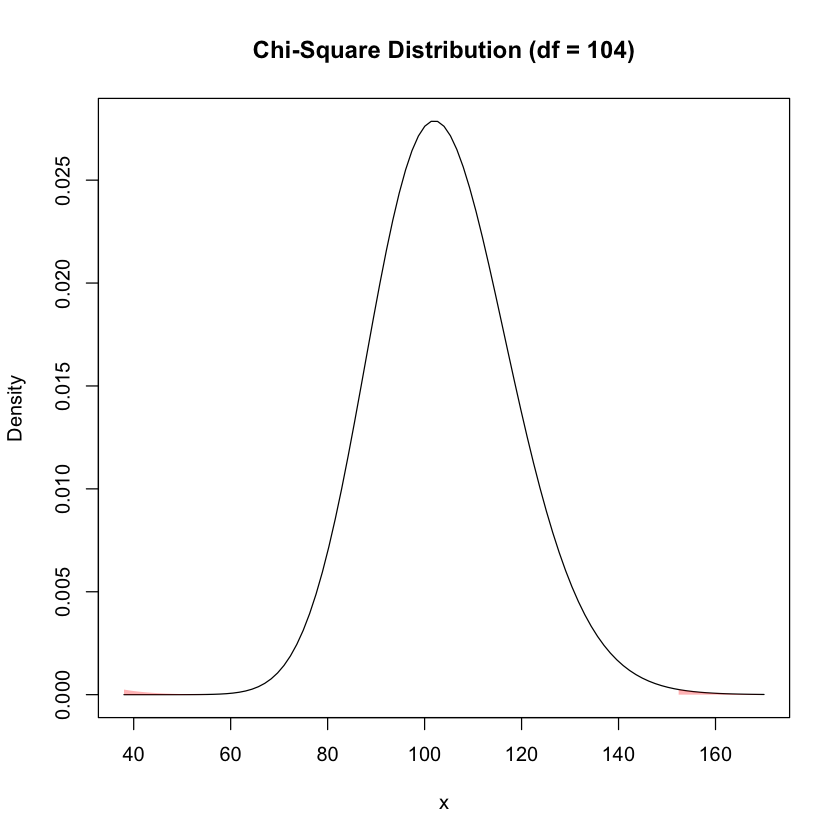

In [1]:
#create density curve
curve(dchisq(x, df = 104), from = 38, to = 170,
main = 'Chi-Square Distribution (df = 104)',
ylab = 'Density',
lwd = 1)

#create vector of u and  values
u_vector <- seq(38, 55.6011)
x_vector <- seq(152.3989, 170)


#create vector of chi-square density values
p_vector <- dchisq(x_vector, df = 104)

#fill in portion of the density plot from value to value
polygon(c(x_vector, rev(x_vector)), c(p_vector, rep(0, length(p_vector))),
        col = adjustcolor('red', alpha=0.3), border = NA)

#fill in portion of the density plot from value to value
polygon(c(u_vector, rev(u_vector)), c(p_vector, rep(0, length(p_vector))),
        col = adjustcolor('red', alpha=0.3), border = NA)

In [2]:
# calculating area to the *right* for chi-squared distribution 
# with inputs of chi-squared statistic and df
# and then multiplying by 2 because need to count area just as far away from mean
# on the left side of the chi-squared distribution since we are working with a not equal
# alternative hypothesis
2*(1-pchisq(152.3989,104))


[1] 0.002813994

What is your conclusion from these results?

#### Your answer:

<div class="alert alert-block alert-danger">
    <b>Local Student Practice</b>: Your Turn To Brainstorm a Question! 
</div>

Develop a question that is related to our local area in which a One Sample Population Standard Deviation Hypothesis Test could be used to answer it. 

#### Your answer:

### Two Samples

For samples taken from two populations, does the difference in the two sample proportions (or sample means) indicate a difference in the two population proportions (or population means)?

##### <div class="alert alert-block alert-success"> Two Sample Population Proportion Hypothesis Test </div>

Null Hypothesis: $H_0: p_1=p_2$ <br>
Alternative Hypothesis: $H_a: p_1<p_2$ OR $H_a: p_1>p_2$ OR $H_a: p_1\neq p_2$

Assumptions:
1. Data obtained by randomization
2. Two independent samples
3. $n_1\hat{p}_1\geq 10$ and $n_1(1-\hat{p}_1)\geq 10$ <br>
$n_2\hat{p}_2\geq 10$ and $n_2(1-\hat{p}_2)\geq 10$ 

If two-sided test (where $H_a: p_1\neq p_2$), replace $\geq 10$ above with $\geq 5$. 

Test Statistic:  $z =\displaystyle \frac{\hat{p}_1-\hat{p}_2}{\sqrt{\hat{p}(1-\hat{p})(\frac{1}{n_1}+\frac{1}{n_2})}}$<br>
where $\hat{p}=\frac{X_1+X_2}{n_1+n_2}$ is the pooled proportion and $X_1$ and $X_2$ are considered the "successes" in the study measured in numbers (not proportions). Here, success just means whatever fits the criteria you are studying. 

<div class="alert alert-block alert-danger">
    <b>Local Example</b>: Prevalence of Food Insecurity in Alabama Counties 
</div>

Food insecurity is defined as "the condition of not having access to sufficient food, or food of an adequate quality, to meet one's basic needs." You want to know if the prevalance of food insecurity is similar across different areas of Alabama. 

Looking at data on Social Needs from the year 2023 (https://datausa.io/profile/geo/birmingham-al/?social-social_needs=food), you see that 14.1% of Jefferson County was food insecure compared to 9.6% in Shelby County. Suppose 1,000 were surveyed in Jefferson County and 1,000 in Shelby County for this study.

Does there appear to be a significantly higher prevalance of food insecurity in Jefferson County compared to Shelby County? By first choosing an appropriate $\alpha$ level, use the tool of hypothesis testing to make your conclusion.  


##### Your answer:

##### <div class="alert alert-block alert-success"> Two Sample Population Mean Hypothesis Test (Two Sample $t$-test) </div>

Null Hypothesis: $H_0: \mu_1=\mu_2$ <br>
Alternative Hypothesis: $H_a: \mu_1<\mu_2$ OR $H_a: \mu_1>\mu_2$ OR $H_a: \mu_1\neq \mu_2$

Assumptions:
1. Data obtained by randomization
2. Two independent samples
3. Approximately normal populations or $n_1, n_2 \geq 30$

Test Statistic: $t=\displaystyle \frac{\bar{x}_1-\bar{x}_2}{\sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}}$

$df=$min$(n_1-1,n_2-1)$



<div class="alert alert-block alert-danger">
    <b>Local Application: </b> Birmingham vs. Huntsville temperatures
</div>

The temperature highs for all 31 days of May 2024 are given here for Birmingham, AL: https://www.accuweather.com/en/us/birmingham/35203/may-weather/346630 and here for Huntsville, AL: https://www.accuweather.com/en/us/huntsville/35801/may-weather/326704?year=2024

Based on these samples, at a significance level of $\alpha=0.05$, can it be concluded that Birmingham is warmer than Huntsville in May of each year?

In [ ]:
#For Birmingham
x <- c(86,87,85,85,89,87,84,87,87,82,78,81,72,79,81,84,74,86,85,86,87,88,88,87,91,92,90,88,86,84,86) 
length(x)
sd(x)
mean(x)

##### Your answer:

### Additional Types of Hypothesis Tests 

##### <div class="alert alert-block alert-success"> Chi-Squared Test of Independence Hypothesis Test </div>

We use this to test if two categorical variables shown in a two-way table (contigency table) are independent.

Reminder from Chapter 3 (part II):

* A __two-way table__ (</em> contingency table </em>) shows the relationship between two categorical variables by listing one variable in the rows and the other variable in the columns with table entries being frequencies.

* The __observed frequencies__ $(O)$ in a two-way table are the frequencies we actually see occur. 

* The __expected frequencies__ $(E)$ in a two-way table are the frequencies we would expect by chance if there were no relationship between the row and the column variables (i.e. assuming the variables are independent). We use this formula to calculate the expected frequency, E, for each cell:
 $$E =\frac{(row total)(column total)}{
n}$$
where $n$ is the grand total.

* The __chi-squared statistic__ is given by $$\chi ^ 2=\Sigma \frac{(O-E)^2}{E}$$
Note: The larger the value of $\chi ^ 2$, the greater the average difference between the observed and expected
frequencies in the cells.

* For two-way tables, __degrees of freedom__ are calculated by $df=(r-1)(c-1)$ where $r$ is number of rows and $c$ is number of columns. 

__Chi-Squared Test of Independence: Hypothesis Test__ 

Null Hypothesis: $H_0$: the variables are independent *(be specific about what the variables are) <br>
Alternative Hypothesis: $H_a$: the variables are dependent *(be specific about what the variables are)

Assumptions:
1. Data obtained by randomization
2. All Expected Values are at least 5. 

Test Statistic: $\chi ^ 2=\Sigma \frac{(O-E)^2}{E}$

$df=(r-1)(c-1)$ where $r$ is number of rows and $c$ is number of columns. 

Note: This will ALWAYS be a right-tailed test.

Conclusions: Rejecting the null means that there is evidence to suggest the variables are dependent. Failing to reject the null means there is not sufficient evidence to say that the variables are dependent (but it does NOT confirm the variables are actually independent). 


<div class="alert alert-block alert-danger">
    <b>Local Example</b>: Pizza Preference and Age
</div>

Suppose a survey is conducted here in Birmingham with the following questions: 1. Which pizza restaurant do you prefer: Slice, Pizza Grace, or Pizzeria G.M.? and 2. Are you over the age of 30? The responses are summarized in the two-way table below. 

<p align="center">
    <img src="pics/Pizza v Age Table.png" alt="Figure 1" style="width:70%;"/>
</p>

Perform an appropriate test to see if pizza restaurant preference is independent of age. 



<p align="center">
    <img src="pics/chisquaredtable.png" alt="Figure 1" style="width:70%;"/>
</p>

In [ ]:
# calculating the exact area to the *right* for chi-squared distribution 
# with inputs of chi-squared statistic and df (instead of using table)
1-pchisq(37.348,2)


##### <div class="alert alert-block alert-success"> Chi-Squared Goodness of Fit </div>

Suppose you do an experiment with more than one possible outcome and there is a certain probability for each of the outcomes. This test is used to gain insight on the probability distribution of this experiment; in other words, to test the entire set of probabilities of the outcomes. 

* The __observed frequencies__ $(O)$ are the frequencies we actually see occur for a certain outcome/category. Either count up the raw data or calculate $f=n\hat{p}.$

* The __expected frequencies__ $(E)$ for each outcome/category are calculated by $E_i=np_i$. (We are assuming our probability distribution is true unless given evidence otherwise so the expected frequencies are based on the probabilities we are testing).


#### Chi-Squared Goodness of Fit: Hypothesis Test 

Null Hypothesis: $H_0$: The correct probability distribution is given below:<br>
$P_{category 1}=$ (fill in probability value)=$p_1$<br>
$P_{category 2}=$ (fill in probability value)=$p_2$<br>
.<br>.<br>.<br>
$P_{category k}=$ (fill in probability value)=$p_k$<br>
Alternative Hypothesis: $H_a$: At least one of the probabilities is not correct. 

Assumptions:
1. Data obtained by randomization
2. All Expected Values are at least 5. 

Test Statistic: $\chi ^ 2=\Sigma \frac{(O-E)^2}{E}$

$df=(k-1)$ where $k$ is number categories (number of different possible outcomes) in the experiment.

Note: This will ALWAYS be a right-tailed test.

Conclusions: Rejecting the null means that there is evidence to suggest the probability distribution as stated is wrong. Failing to reject the null means there is not sufficient evidence to say the probability distribution is wrong (but this does NOT confirm the probabilitity distribution is correct). 


<div class="alert alert-block alert-danger">
    <b>Example</b>: Sharks!
</div>

There are many shark species found in the Caribbean waters and some predominent species found off the coast of Belize are the Nurse, Reef, Black Tip, and Lemon Sharks.

I suspect the following probability distribution for the waters of Belize. 

$H_0$: The correct probability distrution of sharks in the waters of Belize is: <br>
P(Nurse)=0.3 <br>
P(Reef)=0.15 <br>
P(Black Tip)=0.15<br>
P(Lemon)=0.2<br>
P(Other species)=0.2<br>

$H_a$: At least one of the probabilities is wrong.

Suppose I do a study one year and observe the following numbers of sharks.

<p align="center">
    <img src="pics/sharks observed.png" alt="Figure 1" style="width:50%;"/>
</p>




Solution:

I first calculate Expected Frequencies (under the assumption that my probability distribution is correct).

<p align="center">
    <img src="pics/sharks expected.png" alt="Figure 1" style="width:70%;"/>
</p>

Since the data was obtained randomly (a year timeframe was randomly chosen, location and time of day were varied, etc.) and all expected frequencies are greater than or equal to 5, my assumptions are met. 

Calculating the test statistic, I get 
$\chi ^ 2=\Sigma \frac{(O-E)^2}{E}=\frac{(166-180)^2}{180}+\frac{(105-90)^2}{90}+\frac{(91-90)^2}{90}+\frac{(116-120)^2}{120}+\frac{(122-120)^2}{120}\approx 3.7767$
where $df=k-1=5-1=4$. 

Looking at the area to the right of 3.7667 on the chi-squared distribution of $df=$ 4, we calculate a $p-$value of 0.4385 below.



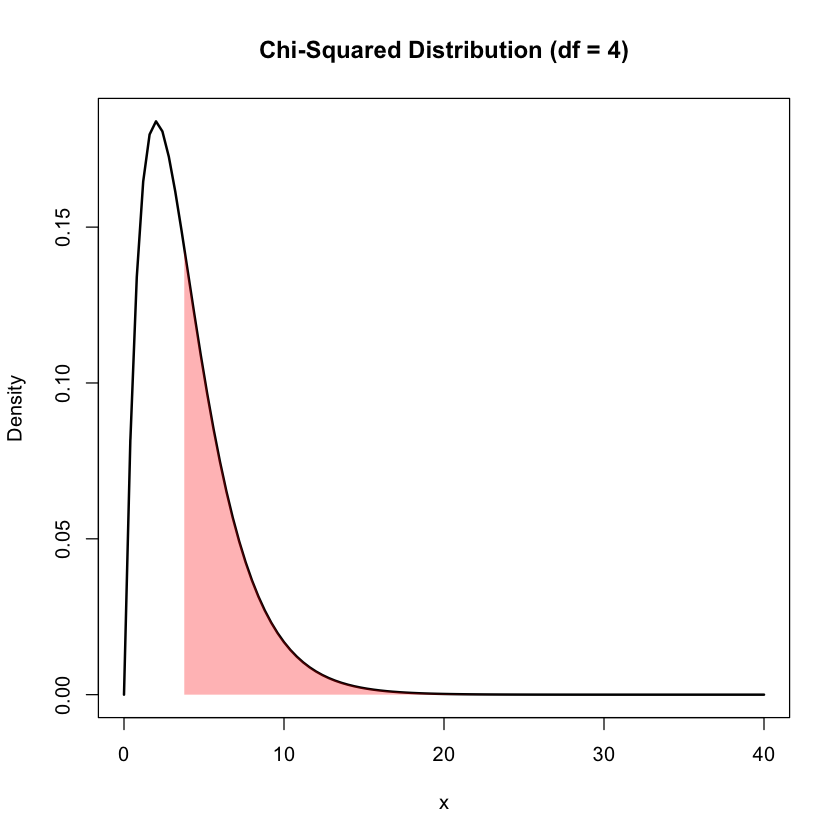

In [5]:
#create density curve
curve(dchisq(x, df = 4), from = 0, to = 40,
main = 'Chi-Squared Distribution (df = 4)',
ylab = 'Density',
lwd = 2)

#create vector of x values
x_vector <- seq(3.7667, 40)

#create vector of chi-square density values
p_vector <- dchisq(x_vector, df = 4)

#fill in portion of the density plot from 0 to 40
polygon(c(x_vector, rev(x_vector)), c(p_vector, rep(0, length(p_vector))),
        col = adjustcolor('red', alpha=0.3), border = NA)

In [6]:
# calculating area to the *right* for chi-squared distribution 
# with inputs of chi-squared statistic and df
1-pchisq(3.7667,4)


[1] 0.4384992

This is greater than an $\alpha$ value of 0.05 so we fail to reject the null hypothesis which means we cannot support the alternative hypothesis. We conclude that there is not enough evidence to suggest that the probabilities listed above are not correct. (We CANNOT say they are definitely correct though). 

<div class="alert alert-block alert-danger">
    <b>Local Example</b>: Your Turn To Brainstorm a Question! 
</div>

Develop a question that is related to our local area in which a Chi-Squared Goodness of Fit Hypothesis Test could be used to answer it. 

#### Your Answer:

##### <div class="alert alert-block alert-success"> Types of Errors </div>

Type I error: when a researcher rejects a null hypothesis that is actually true in the population. <br>
Type II error: when a researcher fails to reject a null hypothesis that is actually false in the population.